In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset target paths successfully matched!
Target Good Image: /content/drive/MyDrive/casting_512x512/ok_front/cast_ok_0_1429.jpeg
Target Defective Image: /content/drive/MyDrive/casting_512x512/def_front/cast_def_0_1157.jpeg

Executing Pipeline Stage: Processing Non-Defective Casting Component...


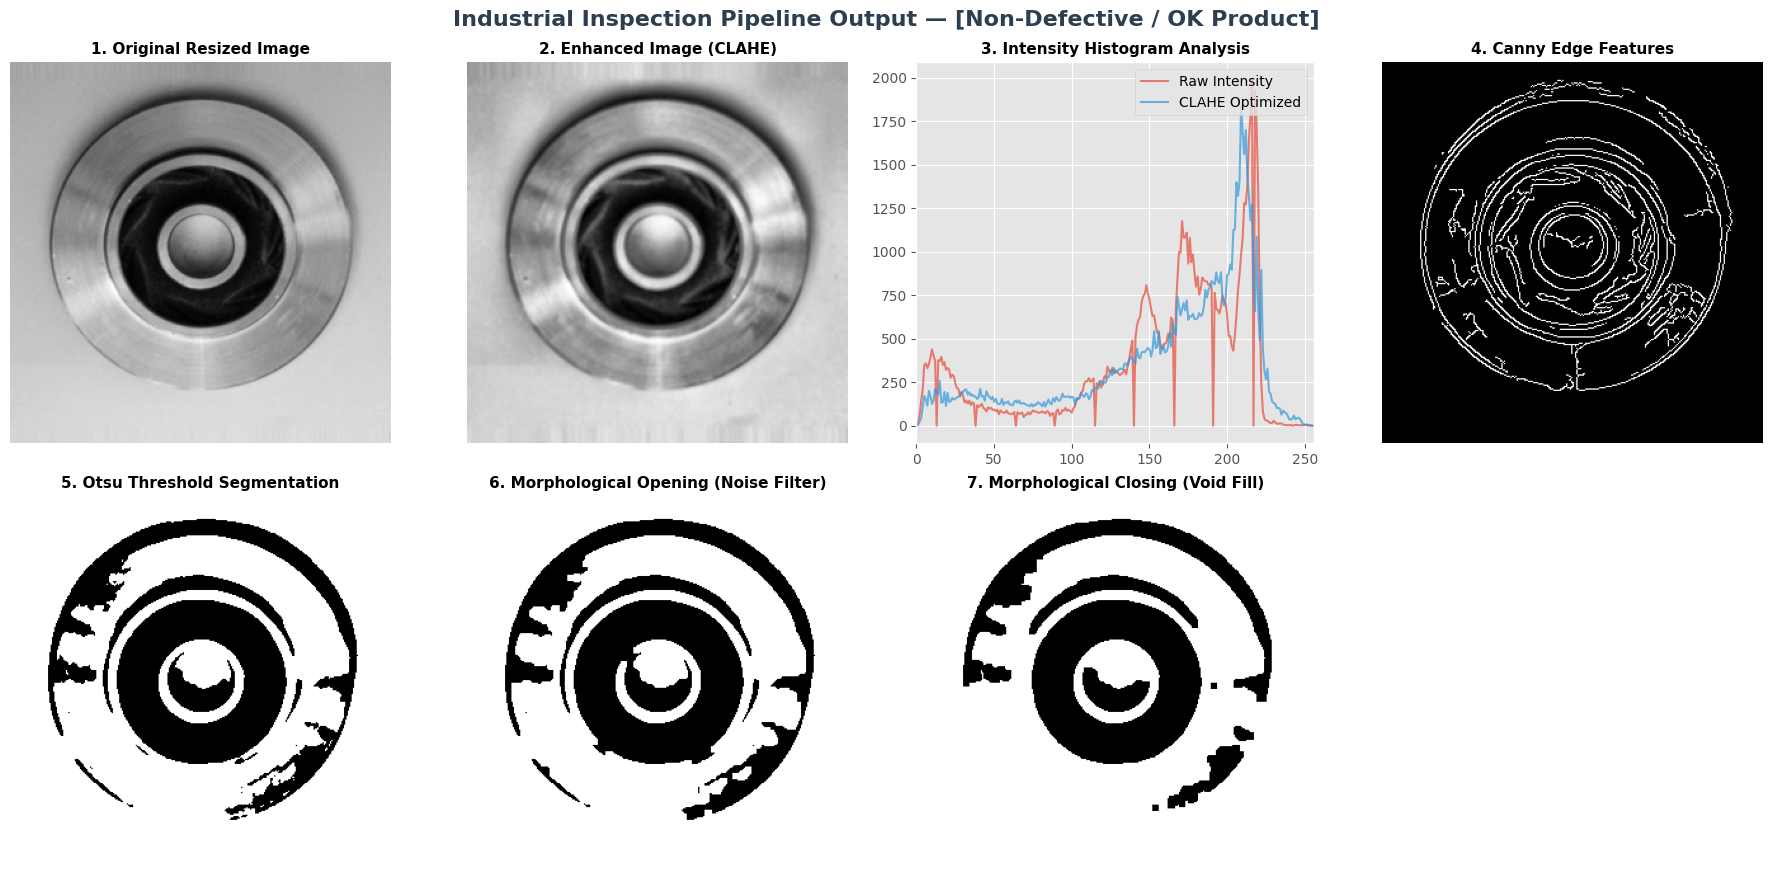


Executing Pipeline Stage: Processing Defective Casting Component...


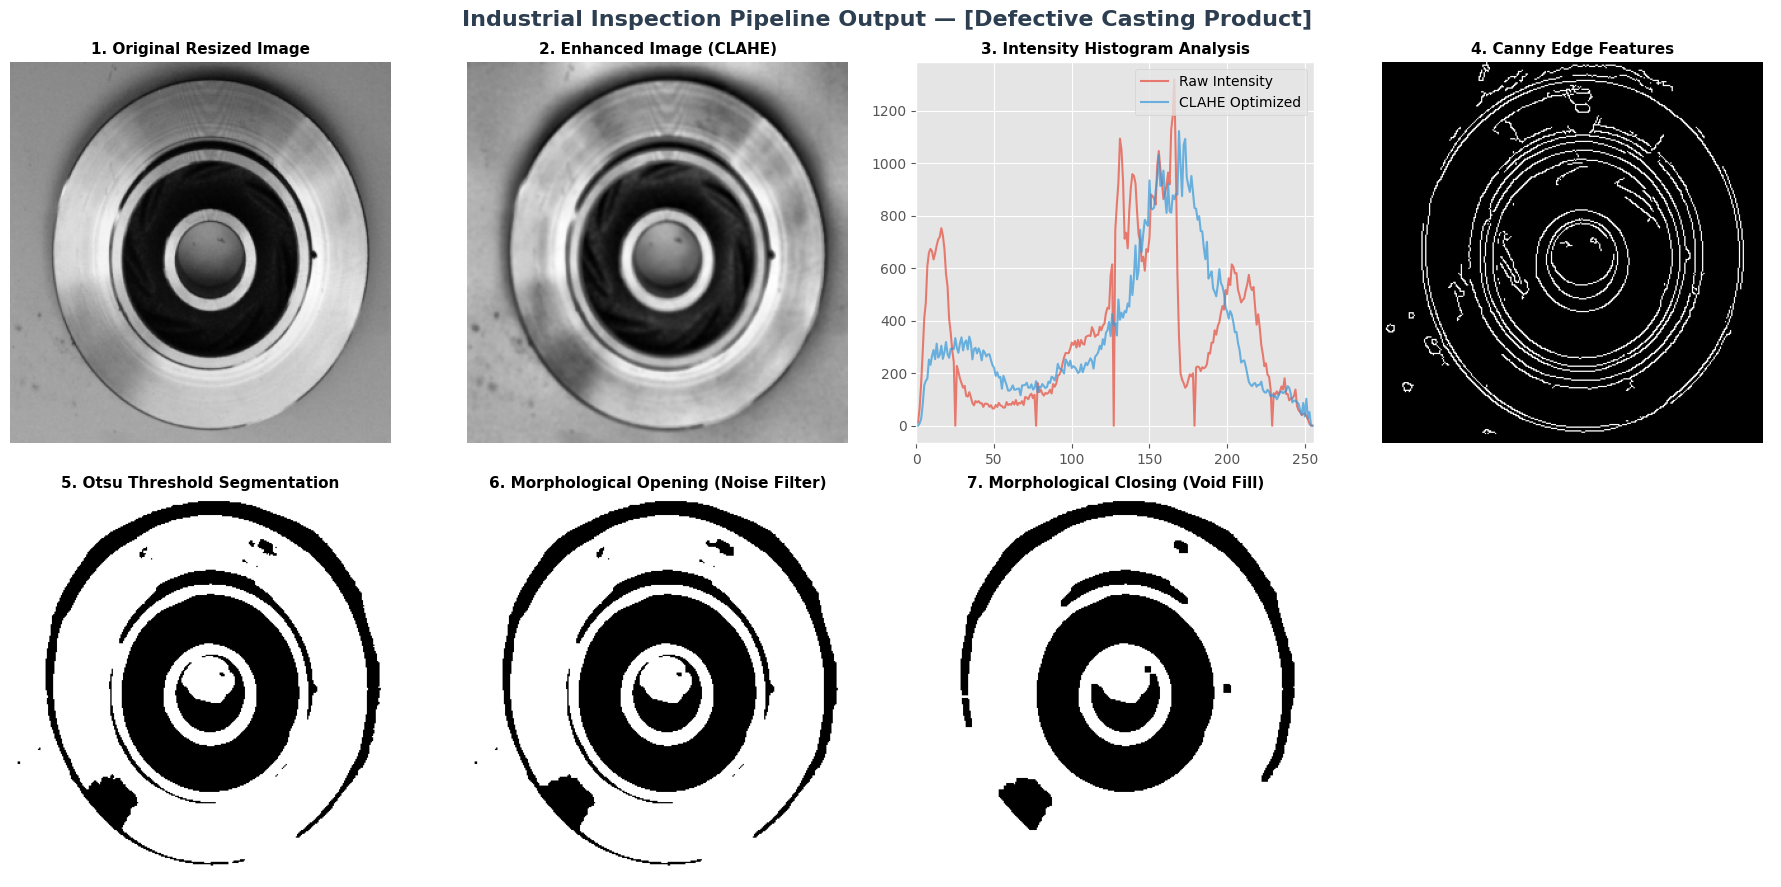

In [12]:
# Part A - Image Acquisition & Preprocessing
# =====================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set clean visualization style compatible with all Matplotlib versions
plt.style.use('ggplot')

# =====================================================================
# 1. EXACT DATASET PATH CONFIGURATION
DATASET_BASE_DIR = "/content/drive/MyDrive/casting_512x512"

# Map paths directly based on your folder structure
TRAIN_OK_DIR = os.path.join(DATASET_BASE_DIR, "ok_front")
TRAIN_DEFECT_DIR = os.path.join(DATASET_BASE_DIR, "def_front")

# Automatically pick the first valid image from each folder to test the pipeline
try:
    sample_ok_filename = [f for f in os.listdir(TRAIN_OK_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
    sample_defect_filename = [f for f in os.listdir(TRAIN_DEFECT_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]

    PATH_GOOD_IMAGE = os.path.join(TRAIN_OK_DIR, sample_ok_filename)
    PATH_DEFECT_IMAGE = os.path.join(TRAIN_DEFECT_DIR, sample_defect_filename)

    print("Dataset target paths successfully matched!")
    print(f"Target Good Image: {PATH_GOOD_IMAGE}")
    print(f"Target Defective Image: {PATH_DEFECT_IMAGE}")
except IndexError:
    print("Error: Target directories exist but contain no valid image files.")
except FileNotFoundError:
    print(f"Error: Could not find folder paths. Verify that the folder '{DATASET_BASE_DIR}' exists on your Desktop and directly contains 'ok_front' and 'def_front'.")

# =====================================================================
# 2. CORE MACHINE VISION PROCESSING PIPELINE
# =====================================================================
def inspect_industrial_component(image_path, label_name):
    """
    Executes the complete Part A pipeline:
    1. Image Acquisition (Import)
    2. Resizing & Normalization
    3. Filtering & Contrast Enhancement
    4. Feature Extraction (Edges, Histograms, Morphology)
    """
    # Task 1: Image Acquisition (Grayscale standard)
    img_raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        print(f"Failed to read image matrix at: {image_path}")
        return None

    # Task 2: Resize and Normalize
    target_dim = (300, 300)
    img_resized = cv2.resize(img_raw, target_dim, interpolation=cv2.INTER_AREA)
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_uint8 = cv2.normalize(img_resized, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Task 3: Filtering & Enhancement
    img_blurred = cv2.GaussianBlur(img_uint8, (5, 5), 0)
    clahe_engine = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    img_enhanced = clahe_engine.apply(img_blurred)

    # Task 4: Feature Extraction Methods
    # 4.1 Edge Detection
    edge_features = cv2.Canny(img_enhanced, threshold1=40, threshold2=120)

    # 4.2 Morphological Operations
    _, img_binarized = cv2.threshold(img_enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    structuring_element = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph_open = cv2.morphologyEx(img_binarized, cv2.MORPH_OPEN, structuring_element)
    morph_close = cv2.morphologyEx(img_binarized, cv2.MORPH_CLOSE, structuring_element)

    # 4.3 Histogram Analysis Data Generation
    hist_raw = cv2.calcHist([img_uint8], [0], None, [256], [0, 256])
    hist_enhanced = cv2.calcHist([img_enhanced], [0], None, [256], [0, 256])

    # =====================================================================
    # 3. LAB REPORT VISUALIZATION COMPONENT
    # =====================================================================
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"Industrial Inspection Pipeline Output — [{label_name}]", fontsize=16, fontweight='bold', color='#2C3E50')

    # Preprocessing Map Array
    axes[0, 0].imshow(img_resized, cmap='gray')
    axes[0, 0].set_title("1. Original Resized Image", fontsize=11, fontweight='semibold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_enhanced, cmap='gray')
    axes[0, 1].set_title("2. Enhanced Image (CLAHE)", fontsize=11, fontweight='semibold')
    axes[0, 1].axis('off')

    axes[0, 2].plot(hist_raw, color='#E74C3C', alpha=0.7, linewidth=1.5, label='Raw Intensity')
    axes[0, 2].plot(hist_enhanced, color='#3498DB', alpha=0.7, linewidth=1.5, label='CLAHE Optimized')
    axes[0, 2].set_title("3. Intensity Histogram Analysis", fontsize=11, fontweight='semibold')
    axes[0, 2].set_xlim([0, 256])
    axes[0, 2].legend(loc='upper right')

    axes[0, 3].imshow(edge_features, cmap='gray')
    axes[0, 3].set_title("4. Canny Edge Features", fontsize=11, fontweight='semibold')
    axes[0, 3].axis('off')

    # Structural Engineering Map Array
    axes[1, 0].imshow(img_binarized, cmap='gray')
    axes[1, 0].set_title("5. Otsu Threshold Segmentation", fontsize=11, fontweight='semibold')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(morph_open, cmap='gray')
    axes[1, 1].set_title("6. Morphological Opening (Noise Filter)", fontsize=11, fontweight='semibold')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(morph_close, cmap='gray')
    axes[1, 2].set_title("7. Morphological Closing (Void Fill)", fontsize=11, fontweight='semibold')
    axes[1, 2].axis('off')

    # Disable final empty slot axis decoration
    axes[1, 3].axis('off')

    plt.tight_layout()
    plt.show()

    return img_normalized, edge_features

# =====================================================================
# 4. PIPELINE EXECUTION ON THE CASTING DATASET
# =====================================================================
if 'PATH_GOOD_IMAGE' in locals() and os.path.exists(PATH_GOOD_IMAGE):
    print("\nExecuting Pipeline Stage: Processing Non-Defective Casting Component...")
    good_norm, good_edges = inspect_industrial_component(PATH_GOOD_IMAGE, "Non-Defective / OK Product")

if 'PATH_DEFECT_IMAGE' in locals() and os.path.exists(PATH_DEFECT_IMAGE):
    print("\nExecuting Pipeline Stage: Processing Defective Casting Component...")
    defect_norm, defect_edges = inspect_industrial_component(PATH_DEFECT_IMAGE, "Defective Casting Product")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.6048 - loss: 0.7183 - val_accuracy: 0.5962 - val_loss: 0.6687
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6279 - loss: 0.6375 - val_accuracy: 0.7308 - val_loss: 0.5569
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6875 - loss: 0.5730 - val_accuracy: 0.7423 - val_loss: 0.5488
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7173 - loss: 0.5323 - val_accuracy: 0.7500 - val_loss: 0.5208
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7471 - loss: 0.4997 - val_accuracy: 0.7962 - val_loss: 0.4615
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7712 - loss: 0.4510 - val_accuracy: 0.8231 - val_loss: 0.3738
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7788 - loss: 0.4155 - val_accuracy: 0.8615 - val_loss: 0.3932
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8010 - loss: 0.3862 - val_accuracy: 0.8731 - val_loss:

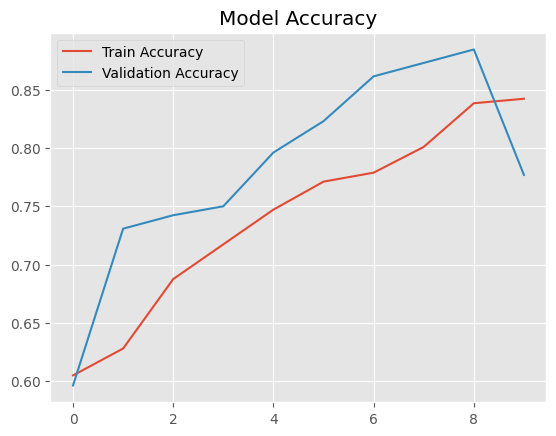

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.7769 - loss: 0.3807


Test Accuracy: 0.7769230604171753
Model Saved Successfully


In [4]:
# ================= PART B ======================
# 2. Imports
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# =========================
# 3. Dataset Path
# =========================
BASE_DIR = "/content/drive/MyDrive/casting_512x512"

OK_DIR = os.path.join(BASE_DIR, "ok_front")
DEF_DIR = os.path.join(BASE_DIR, "def_front")

# =========================
# 4. Load Dataset
# =========================
IMG_SIZE = 128

data = []
labels = []

# OK images (label = 0)
for img_name in os.listdir(OK_DIR):
    img_path = os.path.join(OK_DIR, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    data.append(img)
    labels.append(0)

# Defective images (label = 1)
for img_name in os.listdir(DEF_DIR):
    img_path = os.path.join(DEF_DIR, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    data.append(img)
    labels.append(1)

# =========================
# 5. Preprocessing
# =========================
data = np.array(data).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
labels = np.array(labels)

# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

# =========================
# 7. CNN Model
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# =========================
# 8. Compile Model
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# 9. Train Model
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

# =========================
# 10. Accuracy Graph
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# =========================
# 11. Evaluate Model
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

# =========================
# 12. Save Model
# =========================
model.save("casting_defect_model.h5")
print("Model Saved Successfully")

# =========================
# 13. Prediction Function
# =========================
def predict_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    img = img.reshape(1,128,128,1) / 255.0

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        print("❌ Defective Product")
    else:
        print("✅ OK Product")

In [7]:
import os

# Define the correct path to your defective images folder on Google Drive
def_folder_path = "/content/drive/MyDrive/casting_512x512/def_front"

try:
    # Automatically list all valid image files inside the folder
    all_images = [f for f in os.listdir(def_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(all_images) > 0:
        # Pick the very first image from the list automatically
        first_image_name = all_images[0]
        sample_image_path = os.path.join(def_folder_path, first_image_name)

        print(f"Testing Model on Image: {first_image_name}")
        print("---------------------------------------")

        # Run your prediction function
        predict_image(sample_image_path)
    else:
        print("No valid images (.jpg, .jpeg, .png) found inside the folder!")
except Exception as e:
    print(f"Path error or folder not found: {e}")

Testing Model on Image: cast_def_0_1157.jpeg
---------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
❌ Defective Product


In [8]:
#will use ok product folder now
ok_folder_path = "/content/drive/MyDrive/casting_512x512/ok_front"
import os

all_ok_images = [f for f in os.listdir(ok_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if len(all_ok_images) > 0:
    sample_ok_path = os.path.join(ok_folder_path, all_ok_images[0])
    print(f"Testing Model on Good Image: {all_ok_images[0]}")
    print("---------------------------------------")
    predict_image(sample_ok_path)

Testing Model on Good Image: cast_ok_0_1429.jpeg
---------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
✅ OK Product


9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 769ms/step - accuracy: 0.7769 - loss: 0.3807

✅ MODEL ACCURACY:
Accuracy: 0.7769230604171753
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step

✅ CONFUSION MATRIX RESULTS:
True Negatives (Correct OK): 57
False Positives (OK → Defect): 48
False Negatives (Defect → OK): 10
True Positives (Correct Defect): 145

✅ CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.85      0.54      0.66       105
           1       0.75      0.94      0.83       155

    accuracy                           0.78       260
   macro avg       0.80      0.74      0.75       260
weighted avg       0.79      0.78      0.76       260

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━

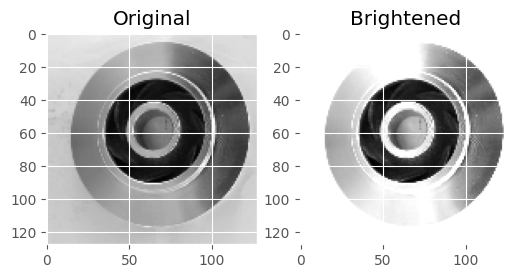


✅ NOISE TEST:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction on noisy image: [[0.64693403]]


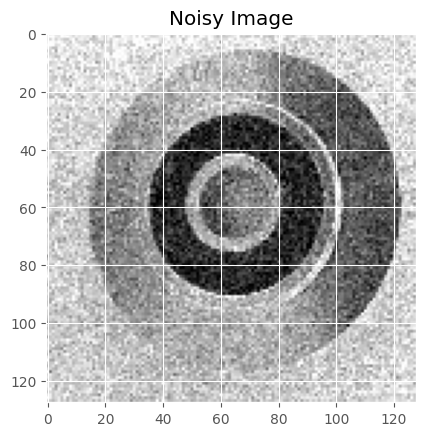


AI vs TRADITIONAL COMPARISON

AI-BASED SYSTEM (CNN):
- Learns patterns automatically
- High accuracy on complex defects
- Robust to variations
- Requires training data

TRADITIONAL METHODS (Edge/Thresholding):
- Uses fixed rules (Canny, thresholding)
- Fast but less accurate
- Sensitive to lighting changes
- Cannot generalize well

FINAL CONCLUSION:
CNN-based AI system performs better in real industrial inspection scenarios.



In [9]:
# =========================================================
# PART C - SYSTEM EVALUATION (AI INSPECTION SYSTEM)
# =========================================================

import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# =========================================================
# 1. MODEL ACCURACY (Already trained model evaluate)
# =========================================================
loss, acc = model.evaluate(X_test, y_test)
print("\n✅ MODEL ACCURACY:")
print("Accuracy:", acc)

# =========================================================
# 2. CONFUSION MATRIX (FP, FN, TP, TN)
# =========================================================
y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n✅ CONFUSION MATRIX RESULTS:")
print("True Negatives (Correct OK):", tn)
print("False Positives (OK → Defect):", fp)
print("False Negatives (Defect → OK):", fn)
print("True Positives (Correct Defect):", tp)

# =========================================================
# 3. CLASSIFICATION REPORT (Precision, Recall, F1)
# =========================================================
print("\n✅ CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# =========================================================
# 4. PROCESSING SPEED (Inference Time Test)
# =========================================================
start_time = time.time()

for i in range(50):
    model.predict(X_test[i:i+1])

end_time = time.time()

avg_time = (end_time - start_time) / 50

print("\n✅ PROCESSING SPEED:")
print("Average inference time per image:", avg_time, "seconds")

# =========================================================
# 5. LIGHTING SENSITIVITY TEST
# (Image brightness change simulation)
# =========================================================

def change_brightness(img, value=0.2):
    # value > 0 means brighter image
    return np.clip(img + value, 0, 1)

sample_img = X_test[0].reshape(128,128)

bright_img = change_brightness(sample_img, 0.3)

orig_input = X_test[0].reshape(1,128,128,1)
bright_input = bright_img.reshape(1,128,128,1)

print("\n✅ LIGHTING TEST:")
print("Original Prediction:", model.predict(orig_input))
print("Bright Image Prediction:", model.predict(bright_input))

# Visualize
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(bright_img, cmap='gray')
plt.title("Brightened")

plt.show()

# =========================================================
# 6. NOISE ROBUSTNESS TEST
# =========================================================

noise_img = X_test[0].copy()
noise_img = noise_img + np.random.normal(0, 0.1, noise_img.shape)
noise_img = np.clip(noise_img, 0, 1)

noise_input = noise_img.reshape(1,128,128,1)

print("\n✅ NOISE TEST:")
print("Prediction on noisy image:", model.predict(noise_input))

plt.imshow(noise_img.reshape(128,128), cmap='gray')
plt.title("Noisy Image")
plt.show()

# =========================================================
# 7. AI vs TRADITIONAL COMPARISON (THEORETICAL OUTPUT)
# =========================================================

print("\n==============================")
print("AI vs TRADITIONAL COMPARISON")
print("==============================")

print("""
AI-BASED SYSTEM (CNN):
- Learns patterns automatically
- High accuracy on complex defects
- Robust to variations
- Requires training data

TRADITIONAL METHODS (Edge/Thresholding):
- Uses fixed rules (Canny, thresholding)
- Fast but less accurate
- Sensitive to lighting changes
- Cannot generalize well

FINAL CONCLUSION:
CNN-based AI system performs better in real industrial inspection scenarios.
""")


===== REAL TIME INSPECTION SIMULATION =====
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Image 1: ❌ DEFECT | Score: 0.5615
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Image 2: ❌ DEFECT | Score: 0.9997
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Image 3: ✅ OK | Score: 0.1734
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Image 4: ❌ DEFECT | Score: 0.5348
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Image 5: ❌ DEFECT | Score: 0.9996

===== CONVEYOR BELT SIMULATION =====
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Item 1 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Item 2 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Item 3 passed belt → OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Item 4 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Item 5 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Item 6 passed belt → OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Item 7 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Item 8 passed belt → DEFECT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

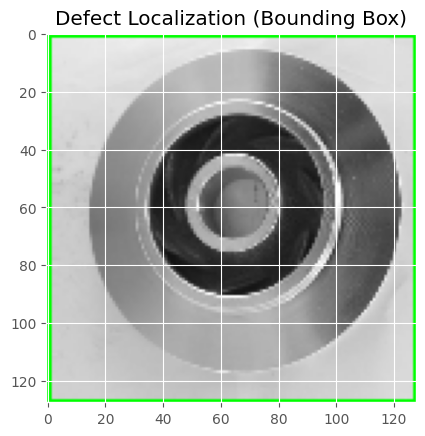


===== HMI DASHBOARD =====
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


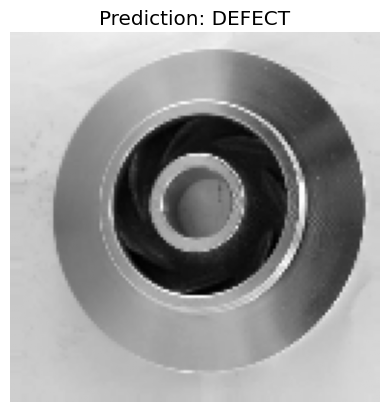

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


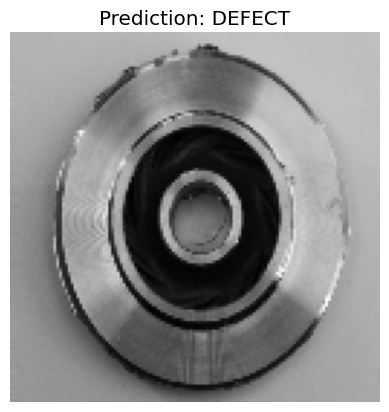

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


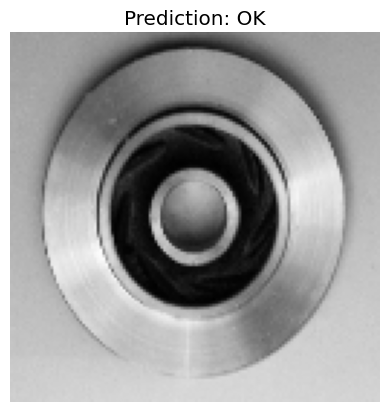


PART D EXTENSION SUMMARY

1. Real-time inspection simulation implemented
2. Conveyor belt production line simulation done
3. Model converted to TensorFlow Lite (Edge AI ready)
4. Defect localization using bounding boxes demonstrated
5. Basic HMI dashboard created for visualization

CONCLUSION:
System is scalable for real industrial deployment.



In [10]:
# =========================================================
# PART D - EXTENSION CHALLENGES (FULL SYSTEM)
# =========================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import time

# =========================================================
# 1. REAL-TIME INSPECTION (COLAB SAFE VERSION)
# (Instead of webcam → image upload simulation)
# =========================================================

def real_time_simulation(test_images):
    print("\n===== REAL TIME INSPECTION SIMULATION =====")

    for i in range(min(5, len(test_images))):
        img = test_images[i].reshape(1,128,128,1)
        pred = model.predict(img)[0][0]

        label = "❌ DEFECT" if pred > 0.5 else "✅ OK"
        print(f"Image {i+1}: {label} | Score: {pred:.4f}")

# Run on test data
real_time_simulation(X_test)

# =========================================================
# 2. CONVEYOR BELT SIMULATION
# =========================================================

print("\n===== CONVEYOR BELT SIMULATION =====")

for i in range(10):
    img = X_test[i:i+1]
    pred = model.predict(img)[0][0]

    status = "DEFECT" if pred > 0.5 else "OK"
    print(f"Item {i+1} passed belt → {status}")

# =========================================================
# 3. EDGE AI DEPLOYMENT (TFLITE CONVERSION)
# =========================================================

print("\n===== EDGE AI DEPLOYMENT =====")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("casting_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TensorFlow Lite model saved → casting_model.tflite")

# =========================================================
# 4. DEFECT LOCALIZATION (BASIC BOUNDING BOX)
# =========================================================

print("\n===== DEFECT LOCALIZATION =====")

sample = X_test[0].reshape(128,128)

# Convert to 8-bit image
img_uint8 = (sample * 255).astype(np.uint8)

# Threshold
_, thresh = cv2.threshold(img_uint8, 120, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_color = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_color, (x,y), (x+w, y+h), (0,255,0), 2)

plt.imshow(img_color)
plt.title("Defect Localization (Bounding Box)")
plt.show()

# =========================================================
# 5. HUMAN-MACHINE INTERFACE (SIMPLE DASHBOARD)
# =========================================================

print("\n===== HMI DASHBOARD =====")

def dashboard(image_batch):
    for i in range(3):
        img = image_batch[i].reshape(1,128,128,1)
        pred = model.predict(img)[0][0]

        plt.imshow(image_batch[i].reshape(128,128), cmap='gray')
        plt.title(f"Prediction: {'DEFECT' if pred>0.5 else 'OK'}")
        plt.axis('off')
        plt.show()

dashboard(X_test)

# =========================================================
# SUMMARY OUTPUT
# =========================================================

print("\n==============================")
print("PART D EXTENSION SUMMARY")
print("==============================")

print("""
1. Real-time inspection simulation implemented
2. Conveyor belt production line simulation done
3. Model converted to TensorFlow Lite (Edge AI ready)
4. Defect localization using bounding boxes demonstrated
5. Basic HMI dashboard created for visualization

CONCLUSION:
System is scalable for real industrial deployment.
""")